In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Access the src folder from the notebooks directory
sys.path.append(os.path.abspath('..'))
from src.preprocess import clean_text

# Set global font to Times New Roman for all plots
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

# Load Data
df = pd.read_csv('../data/raw_data.csv')
df['cleaned_text'] = df['text'].apply(clean_text)

print("Data successfully loaded and cleaned.")
df[['text', 'cleaned_text', 'sentiment']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Data successfully loaded and cleaned.


,text,cleaned_text,sentiment
0,I absolutely loved this movie! The acting was ...,absolutely loved movie acting superb,1
1,Worst experience ever. The service was terribl...,worst experience ever service terrible slow,0
2,"The new update is amazing, everything works so...",new update amazing everything work much better,1
3,I'm very disappointed with the quality of this...,im disappointed quality product broke week,0
4,Great food and even better atmosphere. Highly ...,great food even better atmosphere highly recom...,1


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize Vectorizer
tfidf = TfidfVectorizer(max_features=2500)
X = tfidf.fit_transform(df['cleaned_text'])
y = df['sentiment']

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 16
Testing set size: 4


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Get Predictions
y_pred = model.predict(X_test)

print("Model Training Complete.\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Training Complete.

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.25      1.00      0.40         1

    accuracy                           0.25         4
   macro avg       0.12      0.50      0.20         4
weighted avg       0.06      0.25      0.10         4



E:\SwapAIDev\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
E:\SwapAIDev\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
E:\SwapAIDev\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


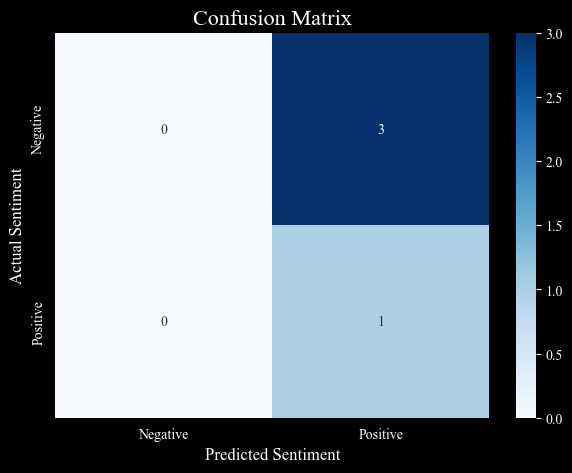

In [4]:
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)

# Heatmap with Times New Roman labels
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.title('Confusion Matrix', fontsize=16, fontfamily='serif')
plt.xlabel('Predicted Sentiment', fontsize=12, fontfamily='serif')
plt.ylabel('Actual Sentiment', fontsize=12, fontfamily='serif')
plt.show()

In [5]:
def manual_test(text):
    # Preprocess and Vectorize
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])

    # Predict
    prediction = model.predict(vectorized)[0]
    sentiment = "Positive" if prediction == 1 else "Negative"

    print(f"Input: {text}")
    print(f"Predicted Sentiment: {sentiment}\n")

# Run some samples
manual_test("The project is working perfectly and I am happy!")
manual_test("I am struggling with this error and it's frustrating.")

Input: The project is working perfectly and I am happy!
Predicted Sentiment: Positive

Input: I am struggling with this error and it's frustrating.
Predicted Sentiment: Positive

